
# Visión Computacional con Python y OpenCV.

## Introducción.

OpenCV es una  biblioteca libre para implementar  algoritmos de visión
computacional originalmente  desarrollada por Intel. La  biblioteca es
sumamente   eficiente  y   fue  desarrollado   en  los   lenguajes  de
programación  C y  C++ pero  su API  puede ser  utilizada desde  otros
lenguajes de programación, como lo son Python, Java y Matlab/Octave.

En este curso aprenderemos a desarrollar algoritmos de Visión Computacional o procesamiento de imágenes utilizando el lenguaje de programación Python y las
bibliotecas de código abierto openCV y numpy.

En esta sesión empezaremos aprendiendo como cargar desde un archivo una imagen y como se almacena ésta en un arreglo multidimensional de numpy.

---
## Cargando una imagen desde un archivo.

Aunque openCV puede recibir imágenes directamente de una cámara o un archivo de video, en este curso utilizaremos únicamente imágenes almacenadas en un archivo.

Como vimos en clase, concebimos una imagen como un arreglo bidimensional de pixeles, donde un pixel es una cantidad que describe la luz asociada a dicho pixel. En las imágenes monocromáticas, el pixel es una cantidad numérica cuyo valor corresponde la intensidad de la luz del pixel, usualmente 0 para la ausencia de luz y un valor máximo (255 cuando usamos un byte por pixel), para la cantidad máxima de luz.

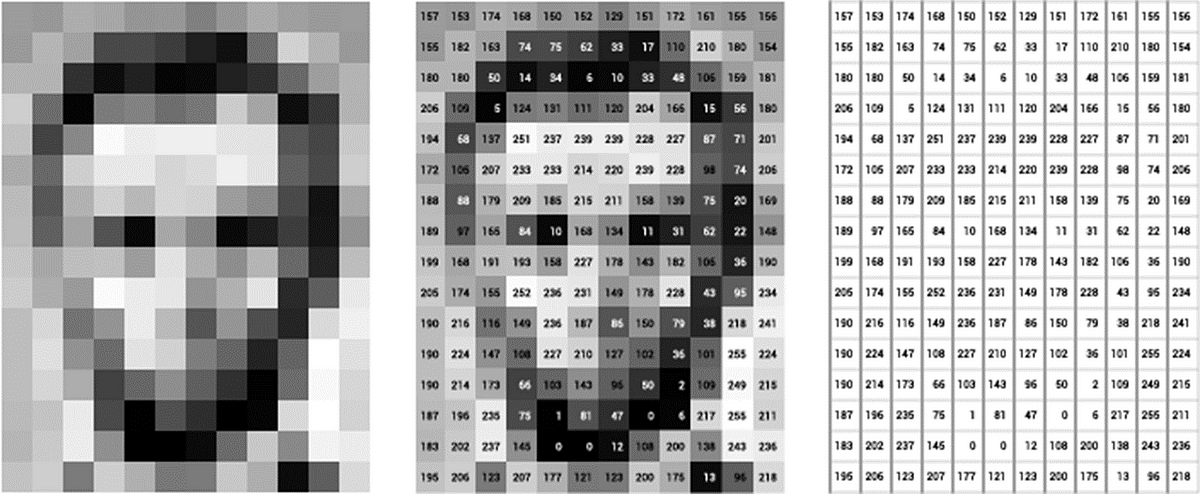



Los pixeles de la imágenes a color están compuestos por un conjunto de valores. Existen varias representaciones de color estándares, como HSV o CIE-Lab, pero en este curso utilizaremos la representación RGB, en donde cada pixel esta representado por tres valores, done cada uno de ellos corresponde la intensidad de la luz roja (R), verde (G) y azul (B) del pixel. Al conjunto de valores asociados a luz de un mismo tipo (roja, verde o azul) se le conoce como Canal. Así decimos que una imagen RGB esta compuesta por tres canales, el canal rojo, el verde y el azul.

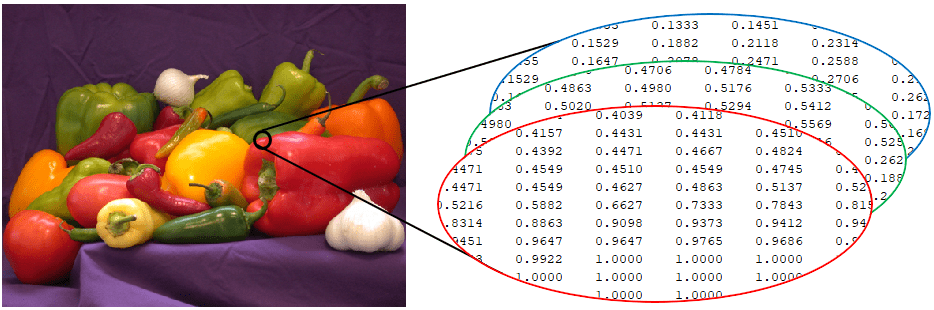

Al igual que las imágenes monocromáticas, usualmente las imagenes RGB utilizan un byte para representar cada uno de los componentes de luz de un pixel. Esto implica que para almacenar un pixels se requieren 24 bits, y se pueden representar \$2^{24} = 16,777,216\$ colores diferentes.

---
## Nomenclatura.

Cuando tratamos con imágenes hay que utilizar la nomenclatura adecuada. Una imagen se almacena como una matriz tridimensional, en donde la tercera dimensión, (el eje \$k\$ en la figura), corresponde al valor que representa el pixel. En caso de imágenes monocromáticas, el valor es un escalar y la matriz solo tiene una dimensión en la dirección \$k\$, esto es tiene solo un *canal*. En una imagen a color RGB, el valor asociado a cada pixel es un vector con tres elementos y entonces matriz se asemeja a la de la figura, en donde cada pixel tiene 4 *canales*.

Cada *canal* puede ser concebido como una matriz bidimensional, con un cierto número de *renglones* y *columnas*, esto correspondería a los ejes 
\$i\$ y \$j\$ de la figura.

Ademas cada celda de la matriz almacena un valor el cual podemos caracterizar por el *tipo*(número flotante o número entero) y la *profundidad*, esto es él número de bits que se requieren para almacenar ese número (usualmente, 8, 16, 32 o 64 bits).

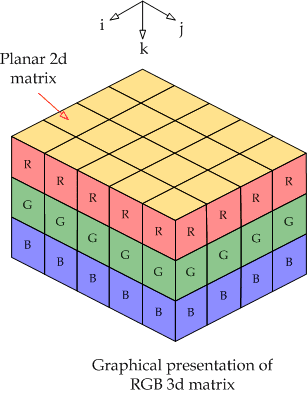

En resumen, a imagen la podemos caracterizar a través de los siguientes elementos:

 * *Renglones*: Cuantos pixeles hay en la dirección vertical de la imagen.
 * *Columnas*: Cuantos pixeles hay en la dirección horizontal de la imagen.
 * *Canales*: Cuantas capas, cada una representando una propiedad de color diferente tiene la imagen.
 * *Profundidad*: El número de bits que tiene cada elemento de la matriz.


---
## Usando openCV.

Para utilizar openCV desde ```Python``` lo primero que debemos hacer es instalar el ambiente de desarrollo de openCV en la computadora en la que vamos a programar. Una opción popular es [Anaconda](https://www.anaconda.com/) una distribución de python orientada a cómputo científico, .

Afortunadamente la documentación del API de openCV se encuentra disponible en linea, en el siguiente sitio: [Documentación oficial de openCV ](https://docs.opencv.org/). Ahí se muestran ligas para acceder a la versión de openCV que deseemos.

En este curso cualquier versión superior a la número 3 es adecuada.

OpenCV depende de la biblioteca [numPy](https://numpy.org/), pues las imágenes con las que opera openCV se almacenan como arreglos n-dimensionales, que se definen como una clase nativa de numPy.

### Importando los módulos.

Para iniciar nuestro desarrollo en openCV lo primero es que debemos importar los módulo de openCV (```cv2```) y numpy.

In [ ]:
import numpy as np
import cv2

---
## Cargando una imagen.

La primera operación que vamos a explorar en openCV es como cargar una imagen. Para eso utilizamos la función ```imread``` de openCV:

La función en Python tiene la siguiente forma:
```
    cv.imread(	filename[, flags]	) -> 	retval
	cv.imread(	filename[, dst[, flags]]	) -> 	dst
```

Lo que hace esta función es cargar una imagen en archivo cuya ruta es la cadena ```filename```. En caso de tener éxito la función regresa ```dst```, un objeto de tipo ```numpy.ndarray``` (arreglo n-dimensional de numPy) que contiene la imagen y en cualquier otro caso regresa un ```None```. Opcionalmente la función puede recibir banderas que modifican su comportamiento. Las más importantes las explicaremos a continuación:

 * ```cv2.IMREAD_GRAYSCALE```: Si usamos esta bandera independientemente del tipo de la imagen (a color o monocromática), esta se cargará como una imagen monocromática (un solo canal).
 * ```cv2.IMREAD_COLOR```: Si usamos esta bandera la imagen se va a almacenar como una imagen a color, independientemente del tipo que sea. Esto implica que si cargamos una imagen monocromática y usamos esta bandera, la imagen se almacenara como una matriz con tres canales, en donde cada canal es igual a los demás.
 * ```cv2.IMREAD_ANYDEPTH```: Si usamos esta bandera una imagen con profundidad de 16 0 32 bits se va cargar como tal, respentando la representación original. Si no se usa, la profundidad de la imágen será ajustada a 8 bits.


---
## Las propiedades de las Imágenes.

Una vez que cargamos las imágenes podemos consultar sus propiedades básicas, que se almacenan en los atributos ```shape``` y ```dtype``` que describen sus dimensiones (renglones, columnas y canales) y profundidad respectivamente como se muestra abajo.

In [ ]:
#Cargamosuna imagen
Ig = cv2.imread("Gatito.png")

print ('\nLas dimensiones de la matriz que almacena la imagen son la siguientes:\n', Ig.shape, ', renglones, columnas y canales respectivamente.')
print ('\n')
print ('El tipo de datos de cada elementos de la matriz es: ', Ig.dtype, '\n\n')
print ('Podemos consultar la profundidad de la imagen (en número de bytes),')
print ('usando el atributo alignment:', Ig.dtype.alignment, '\n')


---
## Desplegando imágenes.

Para desplegar una imagen necesitamos utilizar cuatro funciones de ```openCV```: 

### ```namedWindow```

Esta función define una ventana en donde se desplegará la imagen.
El prototipo de la función es como sigue:
   * ```cv2.namedWindow(	winname[, flags]	) -> 	None```
        * ```winname```: es una cadena que define de manera única el nombre de la ventana.
        * ```flags```: Son bandera opcionales que controlan el comportamiento de la ventana. Algunas de las banderas usuales son las siguientes:
            * ```cv2.WINDOW_NORMAL```: Permite modificar el tamaño de la ventana.
            * ```cv2.WINDOW_AUTOSIZE```: El tamaño de la ventana se ajusta a la imagen y no es posible cambiarlo.
            * ```cv2.WINDOW_FREERATIO```: La relación entre el ancho y alto de la imagen **si** puede ser modificado al cambiar el tamaño de la imagen.
            * ```cv2.WINDOW_KEEPRATIO```: La relación entre el ancho y alto de la imagen **no** puede ser modificado al cambiar el tamaño de la imagen.

### ```imshow```:

Muestra una imagen en una ventana determinada.

El prototipo de la función es como sigue:
 * ```cv.imshow( winname, mat ) -> None```
     * ```winname```: El nombre de la ventana donde se desplegará la imagen.
     * ```mat```: La imagen a desplegar en la ventana.
Para que la imagen sea desplegada, se debera invocarse despues la función ```waitKey``` que explicamos a continuación abajo.

### ```waitKey```:
Espera a que se oprima una tecla. La función bloquea la ejecución del programa un cierto número de milisegundos o hasta que se oprima una tecla, y refresca las ventanas abiertas.

El prototipo de la función es como sigue:
    * ```cv.waitKey(	[, delay]	) -> 	retval```
        * ```delay```: El número de milisegundos que se va a esperar a que se oprima una tecla. Si el valor es cero, se esperará de manera indefinida.
        
La función regresará el código de la tecla que se oprimió o bien el valor -1 si ninguna tecla se oprimió durante el tiempo de espera.


### ```destroyWindow``` y ```destroyAllWindows```
Destruye una ventana o todas las ventanas que se han abierto.

El prototipo de la primera función es como sigue:
   * ```cv.destroyWindow(	winname	) -> 	None```
       * ```winname```: El nombre de la ventana que se va a destruir.
       
El prototipo de la primera función es como sigue:
   * ```cv.destroyAllWindows( ) -> 	None```

Ninguna de las ventanas regresa nada.


## Ejemplos.

A continuación mostraremos algunos ejemplos de como usar estas funciones.

Primero cargaremos una imagen usando la bandera ```cv2.WINDOW_NORMAL```, lo cual nos permitirá modifical el tamaño de la ventana.

No podremos continual la ejecución del programa pues la instrucción ```cv2.waitKey```bloquea el programa. Nótese que las proporciones de la imagen se mantienen.

In [ ]:
cv2.namedWindow("Ventana Gatito",cv2.WINDOW_NORMAL)
cv2.imshow("Ventana Gatito", Ig)
cv2.waitKey(0)
cv2.destroyWindow("Ventana Gatito")

---
En este ejemplo, su utilizan dos banderas, ```cv2.WINDOW_NORMAL``` y ```cv2.WINDOW_FREERATIO```, lo cual permite una ventana a la cual podemos modificar su tamaño, sin mantener la razón entre ancho y alto fija. Notese como se usa el operador ```or``` de ```Python``` (```|```) para combinar ambas banderas.

In [ ]:
Ip=cv2.imread("Pelota.png")
cv2.namedWindow("Ventana Pelota", cv2.WINDOW_NORMAL|cv2.WINDOW_FREERATIO)
cv2.imshow("Ventana Pelota",Ip)
cv2.waitKey(0)
cv2.destroyWindow("Ventana Pelota")

---
También se pueden abrir dos o más ventanas al mismo tiempo, como se muestra abajo.

In [ ]:
#Podemos Mostrar las dos al mismo tiempo:
cv2.namedWindow("Ventana Gatito",cv2.WINDOW_NORMAL)
cv2.namedWindow("Ventana Pelota",cv2.WINDOW_NORMAL)
cv2.imshow("Ventana Gatito", Ig)
cv2.imshow("Ventana Pelota", Ip)
cv2.waitKey(0)
cv2.destroyAllWindows()

---
Aquí mostramos como se puede abrir una ventana por un tiempo determinado. En este caso abrimos una ventana, esperamos 5 segundos (5000 milisegundos) y cerramos la ventana.

In [ ]:
#Waitkey controla cuanto tiempo se espera por una interacción del teclado.
cv2.namedWindow("Ventana Pelota",cv2.WINDOW_NORMAL)
cv2.imshow("Ventana Pelota", Ip)
cv2.waitKey(5000)
cv2.destroyAllWindows()

## Visualizando las rutinas de matplotlib para visualizar imágenes

Si no se requiere ineracción con la imágenes o se quiere evitar el manejar varias ventanas además de la del navegador, también podemos usar funciones de matplotlib para visualizar resultados.

Otra forma de desplegar imagenes, particularmente útil cuando se trabaja en entorno interactivos como ```jupyter notebooks``` es utilizando la biblioteca ``matplotlib``.

Una carácteristica única de ```openCV```, es que al almacenar las imagenes en formato RGB en memoria, se utiliza el primer canal para almacenar la capa azul ('B'), el segundo canal para la capa verde ('G') y el último canal para la capa roja ('R'), lo que hace que la representación sea en realidad un formato 'BGR', en lugar de 'RGB'.

Como las rutinas de visualización de ```matplotlib``` utilizan la forma 'RGB' es necesario convertir la imagen cargada con openCV utilizando la función ```cv2.cvtColor``` como se muestra abajo.

In [ ]:
# Tambien podemos usar matplot lib para desplegar imágenes. 
# Pero para eso nosotros debemos Invertir las capas de la imagen
# del formato BGR nativos de openCV al RGB de matplotlib

import matplotlib.pyplot as plt

# Convert it to RGB format
Ig = cv2.cvtColor(Ig, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(Ig)
plt.show()